In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import export_text

# Load iris dataset
iris = load_iris()
X = iris.data[:,:2]  # we only take the first two features.
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a DecisionTreeClassifier
# clf = DecisionTreeClassifier()
# clf.fit(X_train, y_train)

# # Check accuracy
# y_pred = clf.predict(X_test)
# print(f"Test Accuracy: {accuracy_score(y_test, y_pred)}")
# print(f"Train Accuracy: {accuracy_score(y_train, clf.predict(X_train))}")

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter':['best', 'random'],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01]
}
clf = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy Score:")
print(grid.best_score_)






Best Parameters:
{'ccp_alpha': 0.01, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}

Best Accuracy Score:
0.8066666666666666


In [51]:
clf = DecisionTreeClassifier(ccp_alpha = 0.01, criterion = 'gini', max_depth = 15,
                              max_features = 'sqrt', min_samples_leaf = 1,
                                min_samples_split = 5, splitter = 'random')
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

print(f'Accuracy -> {accuracy_score(y_test,y_pred)}')

Accuracy -> 0.8


In [52]:
clf.feature_importances_

array([0.6149419, 0.3850581])

In [53]:
r = export_text(clf, feature_names=['sepal_length','sepal_width'])
print(r)

|--- sepal_length <= 5.69
|   |--- sepal_width <= 3.00
|   |   |--- sepal_length <= 4.57
|   |   |   |--- class: 0
|   |   |--- sepal_length >  4.57
|   |   |   |--- class: 1
|   |--- sepal_width >  3.00
|   |   |--- sepal_length <= 5.00
|   |   |   |--- class: 0
|   |   |--- sepal_length >  5.00
|   |   |   |--- sepal_width <= 3.53
|   |   |   |   |--- sepal_width <= 3.12
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal_width >  3.12
|   |   |   |   |   |--- class: 0
|   |   |   |--- sepal_width >  3.53
|   |   |   |   |--- class: 0
|--- sepal_length >  5.69
|   |--- sepal_width <= 3.61
|   |   |--- sepal_width <= 2.26
|   |   |   |--- class: 1
|   |   |--- sepal_width >  2.26
|   |   |   |--- sepal_length <= 5.77
|   |   |   |   |--- sepal_width <= 2.57
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal_width >  2.57
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal_length >  5.77
|   |   |   |   |--- sepal_length <= 7.01
|   |   |   |   |   |--- class: 2

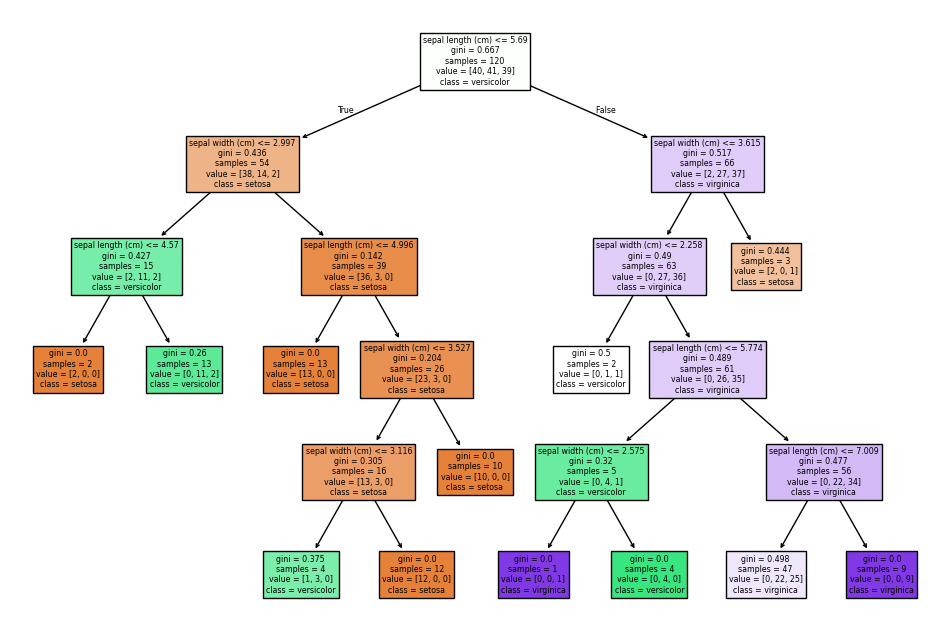

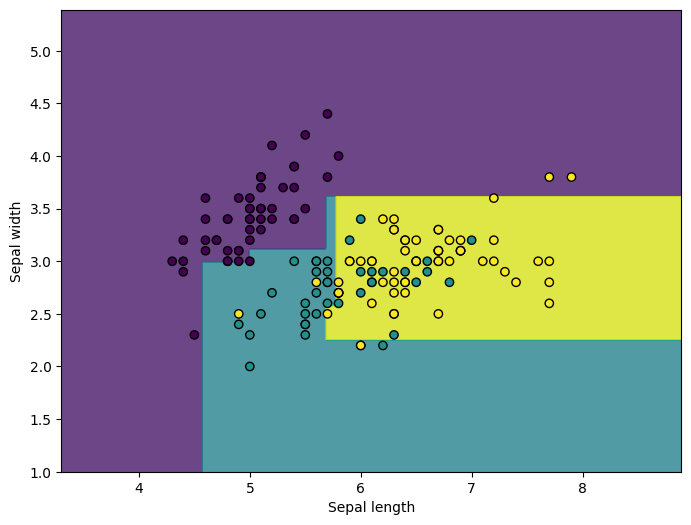

In [54]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names[:2], class_names=iris.target_names)
plt.show()

# Plot the decision boundary
plt.figure(figsize=(8, 6))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

Test R2 Score ->  0.6340159948984869
Train R2 Score ->  0.8028202507835629


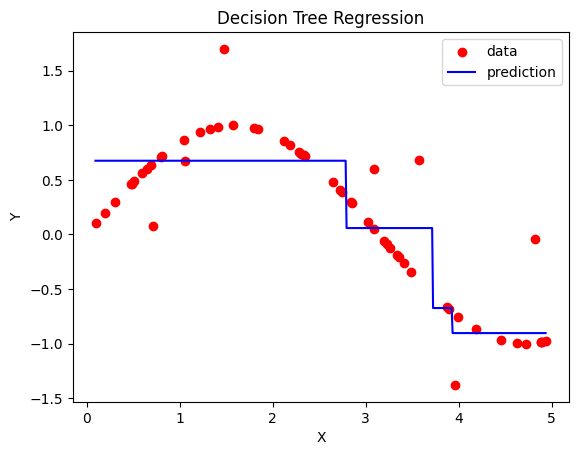

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Generate a non-linear dataset based on the sine function
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - np.random.rand(16))  # add some noise to the data

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a Decision Tree regressor
regressor = DecisionTreeRegressor(max_depth=2 )
regressor.fit(X_train, y_train)

y_pred_reg = regressor.predict(X_test)
from sklearn.metrics import r2_score
print('Test R2 Score -> ',r2_score(y_test,y_pred_reg))
print('Train R2 Score -> ',r2_score(y_train,regressor.predict(X_train)))

# To plot the regression curve, we'll sort the X values and predict Y values for the sorted X
X_grid = np.arange(X[:,0].min(),
                   X[:,0].max(),
                   0.01).reshape(-1,1)
y_grid = regressor.predict(X_grid)

# Plot the training data and the regression curve
plt.scatter(X_train, y_train, color='red', label='data')
plt.plot(X_grid, y_grid, color='blue', label='prediction')
plt.title('Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


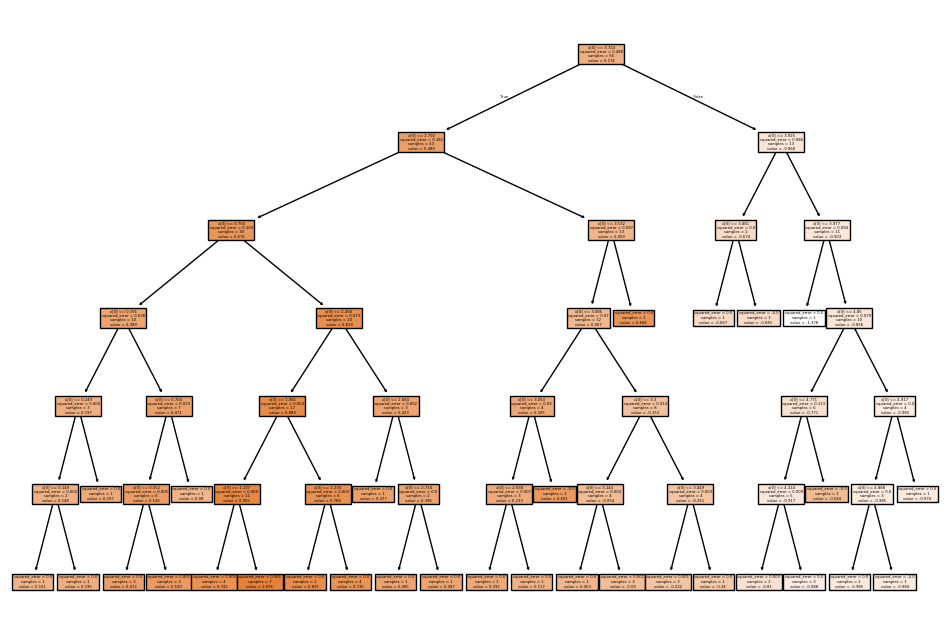

In [39]:
from sklearn.tree import plot_tree
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(regressor, filled=True)
plt.show()